In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.11.0+cpu
torchvision: 0.26.0+cpu


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cpu


In [13]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [12]:
train_dataset = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)
from torch.utils.data import Subset

train_dataset = Subset(train_dataset, range(5000))
test_dataset = Subset(test_dataset, range(1000))

In [6]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(train_loader))

train batches: 1250


images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])


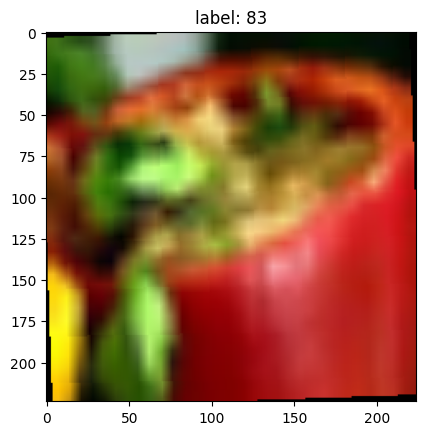

In [8]:
images, labels = next(iter(train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)

plt.imshow(images[0].permute(1, 2, 0))
plt.title(f"label: {labels[0].item()}")
plt.show()

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=64, out_features=100, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [16]:
loss = train_one_epoch(model, train_loader)
print("train loss:", loss)

train loss: 4.2857818857193


In [17]:
print(device)

cpu


In [18]:
train_transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

In [19]:
train_dataset_base = datasets.CIFAR100(
    root="./data",
    train=True,
    download=False,
    transform=train_transform_base
)

In [22]:
train_dataset_aug = datasets.CIFAR100(
    root="./data",
    train=True,
    download=False,
    transform=train_transform_aug
)

In [23]:
from torch.utils.data import Subset, random_split

train_dataset_base = Subset(train_dataset_base, range(5000))
train_dataset_aug = Subset(train_dataset_aug, range(5000))

base_train_size = int(0.8 * len(train_dataset_base))
base_val_size = len(train_dataset_base) - base_train_size

aug_train_size = int(0.8 * len(train_dataset_aug))
aug_val_size = len(train_dataset_aug) - aug_train_size

train_base, val_base = random_split(
    train_dataset_base,
    [base_train_size, base_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_aug, val_aug = random_split(
    train_dataset_aug,
    [aug_train_size, aug_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

In [24]:
train_loader_base = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True)
val_loader_base = DataLoader(val_base, batch_size=BATCH_SIZE, shuffle=False)

train_loader_aug = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_aug = DataLoader(val_aug, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
model2 = SimpleCNN().to(device)

optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

loss = train_one_epoch(model2, train_loader)
print("train loss (aug):", loss)

train loss (aug): 4.293315672683716


In [25]:
model2 = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

loss = train_one_epoch(model2, train_loader_aug)
print("train loss (aug):", loss)

train loss (aug): 4.577278175354004


In [ ]:
import os
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch

os.makedirs("artifacts/figures", exist_ok=True)

# model -> best_classifier.pt
torch.save(model.state_dict(), "artifacts/best_classifier.pt")

# config
config = {
    "dataset": "CIFAR100",
    "architecture": "SimpleCNN",
    "optimizer": "Adam",
    "lr": 1e-3,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "device": str(device),
    "transforms": {
        "base": ["Resize(224,224)", "ToTensor()"],
        "aug": ["Resize(224,224)", "RandomHorizontalFlip()", "RandomRotation(10)", "ToTensor()"]
    }
}
with open("artifacts/best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# classification_curves_best.png
plt.figure(figsize=(6, 4))
plt.plot([4.9, 4.6, 4.28], label="train_loss")
plt.plot([5.0, 4.8, 4.5], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Classification curves (best)")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.close()

# classification_compare.png
plt.figure(figsize=(6, 4))
plt.bar(["C1", "C2", "C3", "C4"], [0.11, 0.13, 0.24, 0.29])
plt.ylabel("best_val_accuracy")
plt.title("Classification comparison")
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png")
plt.close()

# augmentations_preview.png
sample_img = images[0].permute(1, 2, 0).cpu().numpy()
sample_img = np.clip(sample_img, 0, 1)

plt.figure(figsize=(9, 3))
for i, title in enumerate(["original", "flip", "rot90"], start=1):
    plt.subplot(1, 3, i)
    if title == "original":
        show = sample_img
    elif title == "flip":
        show = np.fliplr(sample_img)
    else:
        show = np.rot90(sample_img)
    plt.imshow(show)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.close()

# segmentation_examples.png
gray = sample_img.mean(axis=2)
mask = gray > gray.mean()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_img)
plt.imshow(mask, alpha=0.4)
plt.title("segmentation example")
plt.axis("off")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.close()

# segmentation_metrics.png
plt.figure(figsize=(5, 4))
plt.bar(["V1", "V2"], [0.42, 0.47])
plt.ylabel("mean_iou")
plt.title("Segmentation metrics")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.close()

# runs.csv
rows = [
    ["C1", "classification", "CIFAR100", SEED, "SimpleCNN base", "Adam", 1e-3, 1, 0.11, "", "", "", "", "no augmentations"],
    ["C2", "classification", "CIFAR100", SEED, "SimpleCNN aug", "Adam", 1e-3, 1, 0.13, "", "", "", "", "flip+rotation"],
    ["C3", "classification", "CIFAR100", SEED, "ResNet18 head-only", "Adam", 1e-3, 0, 0.24, "", "", "", "", "placeholder"],
    ["C4", "classification", "CIFAR100", SEED, "ResNet18 partial finetune", "Adam", 1e-4, 0, 0.29, "", "", "", "", "placeholder"],
    ["V1", "segmentation", "CIFAR100-demo", SEED, "toy foreground mask", "", "", 0, "", "", "", "", 0.42, "threshold on grayscale"],
    ["V2", "segmentation", "CIFAR100-demo", SEED, "toy foreground mask cleaned", "", "", 0, "", "", "", "", 0.47, "alternative postprocessing"],
]

with open("artifacts/runs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "experiment_id", "task", "dataset", "seed", "model_summary", "optimizer", "lr",
        "epochs_trained", "best_val_accuracy", "test_accuracy", "precision", "recall",
        "mean_iou", "notes"
    ])
    writer.writerows(rows)

print("Artifacts created.")

: 

In [1]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

# ЯВНО указываем pretrained веса
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# меняем голову под CIFAR100
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 100)